# Predicting House Prices: Regression Analysis of Residential Property Values
**IDRA Data Science & AI - Capstone Project 2026 (Project 9: House Price Prediction)**

This notebook is the reproducible computational record behind the PDF report. It runs top to bottom in this order:

1. Setup and data loading
2. Data quality checks and cleaning
3. Preprocessing (encoding)
4. Exploratory data analysis and visualisation
5. Statistical analysis
6. Train-test split and feature engineering
7. Model development and comparison
8. Final evaluation, error analysis and interpretation

**To run:** put `P_9_Housing.csv` in the same folder as this notebook (in Google Colab, upload it using the Files panel), then choose *Runtime -> Run all*.
Figures are saved to `figures/` and every number used in the report is written to `results.json`.

## 1. Setup and Data Loading

In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed so results are reproducible
DATA_PATH = "P_9_Housing.csv"          # dataset provided in the IDRA LMS
os.makedirs("figures", exist_ok=True)

# Consistent chart style
NAVY, BLUE, ORANGE, GREY = "#1F3864", "#2E75B6", "#ED7D31", "#7F7F7F"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "font.size": 9, "legend.fontsize": 8,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 10})

R = {}   # results dictionary; saved to results.json at the end and used by the report

def py(o):
    """Convert numpy/pandas objects into plain Python so they can be saved as JSON."""
    if isinstance(o, dict):            return {str(k): py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):   return [py(v) for v in o]
    if isinstance(o, (np.integer,)):   return int(o)
    if isinstance(o, (np.floating,)):  return float(o)
    return o

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", bbox_inches="tight")
    plt.show()

In [2]:
raw = pd.read_csv(DATA_PATH)
print("Shape (rows, columns):", raw.shape)
display(raw.head())
print(raw.dtypes)

Shape (rows, columns): (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


The file contains **545 properties and 13 columns**. The target variable is `price` (a continuous number), so this is a **regression** problem. The other 12 columns are candidate predictors: 5 numeric (`area`, `bedrooms`, `bathrooms`, `stories`, `parking`), 6 yes/no property features and 1 three-level category (`furnishingstatus`).

In [3]:
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
cat_cols    = binary_cols + ["furnishingstatus"]
num_cols    = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]

R["n_rows"], R["n_cols"] = int(raw.shape[0]), int(raw.shape[1])
display(raw[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


## 2. Data Quality Checks and Cleaning
Every check below is run on the **raw** data first, so that the report can honestly state what was and was not wrong with it. Cleaning decisions are made only where a problem is actually found.

### 2.1 Missing values, duplicates, invalid values and inconsistent labels

In [4]:
missing = raw.isna().sum()
print("Missing values per column:"); print(missing[missing > 0] if missing.sum() else "None - no missing values in any column")

print("\nDuplicate rows:", raw.duplicated().sum())

# Inconsistent labels: leading/trailing spaces or mixed capitalisation would create fake categories
label_issues = int(sum((raw[c] != raw[c].str.strip().str.lower()).sum() for c in cat_cols))
print("Cells with whitespace / capitalisation problems:", label_issues)
for c in cat_cols:
    print(f"  {c:17s}", sorted(raw[c].unique()))

# Validity: price, area, bedrooms, bathrooms, stories must be > 0; parking may legitimately be 0 (no parking) but not negative
positive_cols = ["price", "area", "bedrooms", "bathrooms", "stories"]
invalid = int((raw[positive_cols] <= 0).sum().sum() + (raw["parking"] < 0).sum())
print("\nImpossible values (zero/negative where not allowed):", invalid)
display(raw[num_cols].agg(["min", "max"]).T)

# Sanity check on the price-per-area ratio (catches impossible price/area combinations)
ppa = raw["price"] / raw["area"]
print(f"\nPrice per unit area: min={ppa.min():,.0f}, median={ppa.median():,.0f}, max={ppa.max():,.0f}")

R["before"] = dict(rows=len(raw), columns=raw.shape[1], missing_cells=int(raw.isna().sum().sum()),
                   duplicate_rows=int(raw.duplicated().sum()), label_issues=label_issues,
                   invalid_numeric=invalid,
                   text_columns=int(raw.select_dtypes(exclude="number").shape[1]))
R["ppa"] = dict(min=ppa.min(), median=ppa.median(), max=ppa.max())
R["ranges"] = raw[num_cols].agg(["min", "max"]).T.to_dict("index")

Missing values per column:
None - no missing values in any column

Duplicate rows: 0
Cells with whitespace / capitalisation problems: 0
  mainroad          ['no', 'yes']
  guestroom         ['no', 'yes']
  basement          ['no', 'yes']
  hotwaterheating   ['no', 'yes']
  airconditioning   ['no', 'yes']
  prefarea          ['no', 'yes']
  furnishingstatus  ['furnished', 'semi-furnished', 'unfurnished']

Impossible values (zero/negative where not allowed): 0


,min,max
price,1750000,13300000
area,1650,16200
bedrooms,1,6
bathrooms,1,4
stories,1,4
parking,0,3



Price per unit area: min=270, median=952, max=2,640


**Finding:** the dataset is already very clean. There are no missing values, no duplicate rows, no inconsistent labels and no impossible values. Because nothing needs fixing, **no rows are dropped and no values are altered**; removing or imputing anything here would only damage good data. The one genuine preparation task is that seven columns are stored as text and must be converted before modelling.

### 2.2 Outlier check (IQR rule)

In [5]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = {}
for c in ["price", "area"]:
    lo, hi = iqr_bounds(raw[c])
    n_out = int(((raw[c] < lo) | (raw[c] > hi)).sum())
    outliers[c] = dict(lower=lo, upper=hi, n_outliers=n_out, pct=100 * n_out / len(raw))
    print(f"{c:6s} upper fence = {hi:,.0f}   outliers = {n_out} ({100*n_out/len(raw):.1f}% of rows)")
R["outliers"] = outliers

# Are the extreme-area homes plausible? Look at the largest ones
display(raw.sort_values("area", ascending=False).head(6))

price  upper fence = 9,205,000   outliers = 15 (2.8% of rows)
area   upper fence = 10,500   outliers = 12 (2.2% of rows)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
403,3500000,12944,3,1,1,yes,no,no,no,no,0,no,unfurnished
211,4900000,12900,3,1,1,yes,no,no,no,no,2,no,furnished


**Decision: retain the outliers.** About 3% of homes are flagged on price and about 2% on area. These are large or high-end properties, not data-entry errors: their price-per-area values are in a normal range and the largest-area homes are not priced impossibly. Real luxury properties are exactly the homes a valuation model must eventually handle, and with only 545 rows, deleting 15-25 of them would throw away information. Instead of deleting them, the skew they cause is handled later with a log transformation.

### 2.3 Fixing data types and validating the result

In [6]:
df = raw.copy()
for c in cat_cols:
    df[c] = df[c].str.strip().str.lower().astype("category")   # standardise text, store as categorical

after = dict(rows=len(df), columns=df.shape[1], missing_cells=int(df.isna().sum().sum()),
             duplicate_rows=int(df.duplicated().sum()),
             label_issues=int(sum((df[c].astype(str) != df[c].astype(str).str.strip().str.lower()).sum() for c in cat_cols)),
             invalid_numeric=int((df[positive_cols] <= 0).sum().sum() + (df["parking"] < 0).sum()),
             categorical_columns=int(df.select_dtypes("category").shape[1]))
R["after"] = after

# Validation: prove the dataset is in the state we claim
assert after["rows"] == R["before"]["rows"]
assert after["missing_cells"] == 0 and after["duplicate_rows"] == 0 and after["invalid_numeric"] == 0
print("Validation passed:", after)
print(df.dtypes)

Validation passed: {'rows': 545, 'columns': 13, 'missing_cells': 0, 'duplicate_rows': 0, 'label_issues': 0, 'invalid_numeric': 0, 'categorical_columns': 7}
price                  int64
area                   int64
bedrooms               int64
bathrooms              int64
stories                int64
mainroad            category
guestroom           category
basement            category
hotwaterheating     category
airconditioning     category
parking                int64
prefarea            category
furnishingstatus    category
dtype: object


## 3. Preprocessing: Encoding Categorical Variables
Machine-learning models need numbers, so:
* The six **yes/no** columns become **1/0** indicators.
* `furnishingstatus` (three unordered levels) is **one-hot encoded**, dropping one level (*furnished*) as the reference category to avoid perfectly redundant columns.

These encodings use a fixed rule and learn nothing from the data, so doing them before the train-test split cannot leak information. **Scaling is different** (it learns a mean and standard deviation), so it is done later inside a pipeline fitted on the training data only.

In [7]:
data = df.copy()
for c in binary_cols:
    data[c] = (data[c] == "yes").astype(int)
data = pd.get_dummies(data, columns=["furnishingstatus"], drop_first=True, dtype=int)

print("Encoded shape:", data.shape)
print("Columns:", list(data.columns))
display(data.head())

Encoded shape: (545, 14)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## 4. Exploratory Data Analysis and Visualisation
The aim is to understand the target and its relationships, and to use that understanding to justify modelling decisions. Prices are shown in **millions** for readability.

### 4.1 The target variable: price

Mean = 4,766,729   Median = 4,340,000   Skewness = 1.21
Skewness of log(price) = 0.14


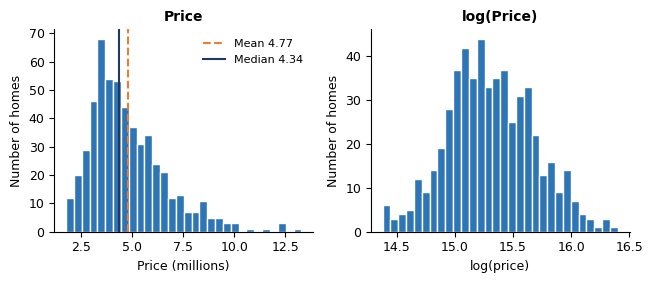

In [8]:
price_m = df["price"] / 1e6
R["price_summary"] = dict(mean=df.price.mean(), median=df.price.median(), std=df.price.std(),
                          skew=df.price.skew(), log_skew=np.log(df.price).skew(), min=df.price.min(), max=df.price.max())
print(f"Mean = {df.price.mean():,.0f}   Median = {df.price.median():,.0f}   Skewness = {df.price.skew():.2f}")
print(f"Skewness of log(price) = {np.log(df.price).skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(6.6, 2.9))
ax[0].hist(price_m, bins=30, color=BLUE, edgecolor="white")
ax[0].axvline(price_m.mean(), color=ORANGE, ls="--", label=f"Mean {price_m.mean():.2f}")
ax[0].axvline(price_m.median(), color=NAVY, ls="-", label=f"Median {price_m.median():.2f}")
ax[0].set(title="Price", xlabel="Price (millions)", ylabel="Number of homes"); ax[0].legend(frameon=False)
ax[1].hist(np.log(df.price), bins=30, color=BLUE, edgecolor="white")
ax[1].set(title="log(Price)", xlabel="log(price)", ylabel="Number of homes")
save_fig("fig1_price_distribution")

Price is **right-skewed** (skewness about 1.2): most homes cluster at moderate prices while a smaller number of expensive homes stretch the right tail, pulling the mean above the median. After taking logs the distribution is close to symmetric (skewness near zero). This motivates modelling `log(price)` as an option.

### 4.2 The most important numeric predictor: area

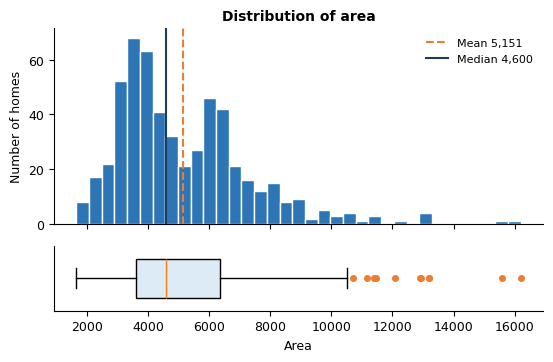

In [9]:
R["area_summary"] = dict(mean=df.area.mean(), median=df.area.median(), skew=df.area.skew(),
                         log_skew=np.log(df.area).skew())
fig, (a1, a2) = plt.subplots(2, 1, figsize=(5.6, 3.7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
a1.hist(df.area, bins=35, color=BLUE, edgecolor="white")
a1.axvline(df.area.mean(), color=ORANGE, ls="--", label=f"Mean {df.area.mean():,.0f}")
a1.axvline(df.area.median(), color=NAVY, label=f"Median {df.area.median():,.0f}")
a1.set(title="Distribution of area", ylabel="Number of homes"); a1.legend(frameon=False)
a2.boxplot(df.area, vert=False, widths=0.6, patch_artist=True, boxprops=dict(facecolor="#DDEBF7"),
           flierprops=dict(marker="o", markerfacecolor=ORANGE, markeredgecolor=ORANGE, markersize=4))
a2.set(xlabel="Area", yticks=[])
save_fig("fig2_area_distribution")

### 4.3 Amenities: do homes with a feature cost more?

,feature,n_no,n_yes,median_no,median_yes,diff_pct
4,airconditioning,373,172,3885000.0,5757500.0,48.2
0,mainroad,77,468,3290000.0,4550000.0,38.3
5,prefarea,417,128,4095000.0,5582500.0,36.3
1,guestroom,448,97,4165000.0,5495000.0,31.9
3,hotwaterheating,520,25,4329500.0,5383000.0,24.3
2,basement,354,191,4077500.0,4900000.0,20.2


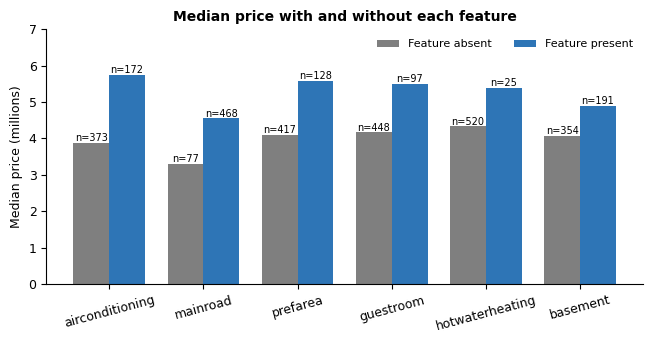

In [10]:
rows = []
for c in binary_cols:
    g = df.groupby(c, observed=True)["price"]
    n, med = g.count(), g.median()
    rows.append(dict(feature=c, n_no=int(n["no"]), n_yes=int(n["yes"]),
                     median_no=med["no"], median_yes=med["yes"],
                     diff_pct=100 * (med["yes"] / med["no"] - 1)))
amen = pd.DataFrame(rows).sort_values("diff_pct", ascending=False)
R["amenity_table"] = amen.to_dict("records")
display(amen.round(1))

fig, ax = plt.subplots(figsize=(6.6, 3.5))
x, w = np.arange(len(amen)), 0.38
b1 = ax.bar(x - w/2, amen.median_no / 1e6, w, color=GREY, label="Feature absent")
b2 = ax.bar(x + w/2, amen.median_yes / 1e6, w, color=BLUE, label="Feature present")
for bars, ns in ((b1, amen.n_no), (b2, amen.n_yes)):
    for b, n in zip(bars, ns):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f"n={n}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(amen.feature, rotation=15)
ax.set(ylabel="Median price (millions)", title="Median price with and without each feature"); ax.set_ylim(0, 7)
ax.legend(frameon=False, loc="upper right", ncol=2)
save_fig("fig3_amenities_median_price")

### 4.4 Size and quality indicators: bedrooms, bathrooms, stories, parking, furnishing, amenity count

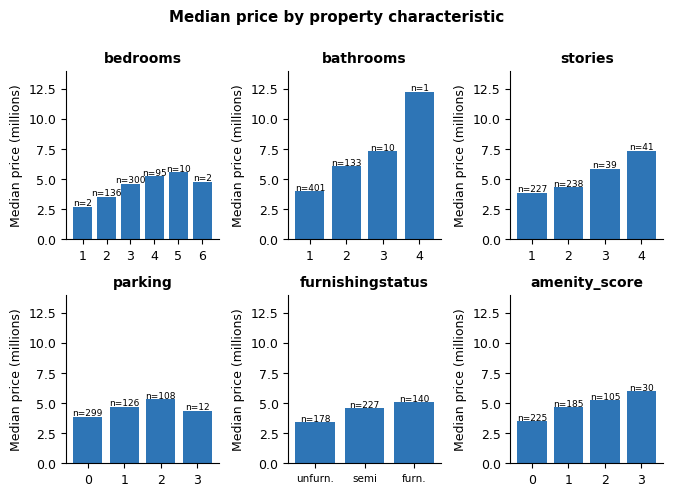

In [11]:
data["amenity_score"] = data[["guestroom", "basement", "hotwaterheating", "airconditioning"]].sum(axis=1)
panels = [("bedrooms", df["bedrooms"]), ("bathrooms", df["bathrooms"]), ("stories", df["stories"]),
          ("parking", df["parking"]), ("furnishingstatus", df["furnishingstatus"].astype(str)),
          ("amenity_score", data["amenity_score"])]
fig, axes = plt.subplots(2, 3, figsize=(6.8, 4.9))
count_tables = {}
for ax, (name, s) in zip(axes.ravel(), panels):
    t = df["price"].groupby(s).agg(["median", "count"])
    if name == "furnishingstatus":
        t = t.loc[["unfurnished", "semi-furnished", "furnished"]]
    count_tables[name] = {str(k): dict(median=v["median"], count=int(v["count"])) for k, v in t.iterrows()}
    ax.bar(t.index.astype(str), t["median"] / 1e6, color=BLUE)
    for i, (m, n) in enumerate(zip(t["median"], t["count"])):
        ax.text(i, m / 1e6 + 0.08, f"n={n}", ha="center", fontsize=6.5)
    ax.set(title=name, ylabel="Median price (millions)")
    ax.set_ylim(0, 14)
    if name == "furnishingstatus":
        ax.set_xticks(range(len(t))); ax.set_xticklabels(["unfurn.", "semi", "furn."], fontsize=7.5)
R["count_tables"] = count_tables
fig.suptitle("Median price by property characteristic", fontweight="bold", y=1.0)
save_fig("fig4_price_by_characteristics")

### 4.5 Relationship between area and price

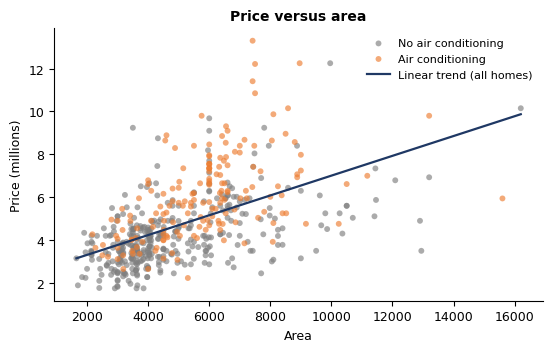

In [12]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for flag, col, lab in ((0, GREY, "No air conditioning"), (1, ORANGE, "Air conditioning")):
    m = data["airconditioning"] == flag
    ax.scatter(data.loc[m, "area"], data.loc[m, "price"] / 1e6, s=18, alpha=0.65, color=col, label=lab, edgecolor="none")
slope, intercept = np.polyfit(data["area"], data["price"] / 1e6, 1)
xs = np.linspace(data["area"].min(), data["area"].max(), 100)
ax.plot(xs, slope * xs + intercept, color=NAVY, lw=1.6, label="Linear trend (all homes)")
ax.set(xlabel="Area", ylabel="Price (millions)", title="Price versus area"); ax.legend(frameon=False)
save_fig("fig5_area_vs_price")

### 4.6 Correlation analysis

Largest predictor-predictor correlation: ('bedrooms', 'stories') 0.409


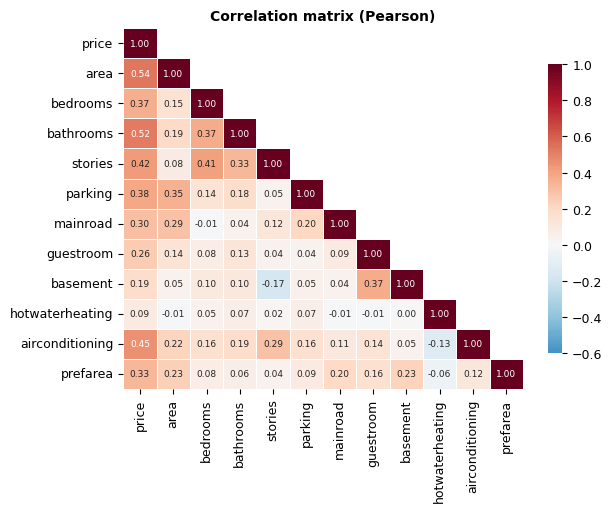

,correlation with price
area,0.536
bathrooms,0.518
airconditioning,0.453
stories,0.421
parking,0.384
bedrooms,0.366
prefarea,0.330
mainroad,0.297
guestroom,0.256
basement,0.187


In [13]:
corr_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"] + binary_cols
corr = data[corr_cols].corr()
R["corr_with_price"] = corr["price"].drop("price").sort_values(ascending=False).to_dict()

# Largest correlation between two PREDICTORS (multicollinearity check)
pred_corr = corr.drop(index="price", columns="price").abs().where(~np.eye(len(corr) - 1, dtype=bool)).stack()
pair = pred_corr.idxmax()
R["max_predictor_corr"] = dict(pair=list(pair), value=corr.loc[pair[0], pair[1]])
print("Largest predictor-predictor correlation:", pair, round(corr.loc[pair[0], pair[1]], 3))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=1,
            annot_kws={"size": 6.5}, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix (Pearson)")
save_fig("fig6_correlation_heatmap")
display(corr["price"].drop("price").sort_values(ascending=False).round(3).to_frame("correlation with price"))

## 5. Statistical Analysis
Descriptive statistics for the numeric variables. Where a distribution is skewed, the **median** is a more representative centre than the **mean**.

In [14]:
stat_rows = []
for c in ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]:
    s = df[c]; q1, q3 = s.quantile([0.25, 0.75])
    stat_rows.append(dict(variable=c, mean=s.mean(), median=s.median(), mode=s.mode().iloc[0],
                          std=s.std(), variance=s.var(), iqr=q3 - q1, skew=s.skew(), min=s.min(), max=s.max()))
stats = pd.DataFrame(stat_rows)
R["stats_table"] = stats.to_dict("records")
display(stats.round(2))

,variable,mean,median,mode,std,variance,iqr,skew,min,max
0,price,4766729.25,4340000.0,3500000,1870439.62,3.498544e+12,2310000.0,1.21,1750000,13300000
1,area,5150.54,4600.0,6000,2170.14,4.709512e+06,2760.0,1.32,1650,16200
2,bedrooms,2.97,3.0,3,0.74,5.400000e-01,1.0,0.50,1,6
3,bathrooms,1.29,1.0,1,0.50,2.500000e-01,1.0,1.59,1,4
4,stories,1.81,2.0,2,0.87,7.500000e-01,1.0,1.08,1,4
5,parking,0.69,0.0,0,0.86,7.400000e-01,1.0,0.84,0,3


## 6. Train-Test Split and Feature Engineering
The data is split **80 % / 20 %** (436 training rows, 109 test rows) with a fixed random seed. From this point the **test set is not used for any decision**: feature and model choices are made using cross-validation *inside the training set only*.

In [15]:
feature_cols = [c for c in data.columns if c not in ("price", "amenity_score")]
X, y = data[feature_cols].copy(), data["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
R["split"] = dict(train=len(X_train), test=len(X_test), n_features=X.shape[1], features=list(X.columns))
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Features:", list(X.columns))

Train: (436, 13)  Test: (109, 13)
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


### 6.1 Candidate engineered features
Four ideas are tested. Each is kept **only if it lowers the 5-fold cross-validated RMSE** of a simple linear model (on log-price) fitted on the training data.
* `log_area` - reduces the right-skew of area (seen in Figure 2)
* `amenity_score` - count of guestroom, basement, hot water and air conditioning
* `area_per_bedroom` and `bath_per_bedroom` - ratio features

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model, X_, y_):
    return -cross_val_score(model, X_, y_, cv=kf, scoring="neg_root_mean_squared_error").mean()

def make_linear(log_target):
    pipe = make_pipeline(StandardScaler(), LinearRegression())   # scaler is fitted inside each CV fold / on train only
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)
    return pipe

def add_candidates(X_):
    Z = X_.copy()
    Z["log_area"] = np.log(Z["area"])
    Z["amenity_score"] = Z[["guestroom", "basement", "hotwaterheating", "airconditioning"]].sum(axis=1)
    Z["area_per_bedroom"] = Z["area"] / Z["bedrooms"]
    Z["bath_per_bedroom"] = Z["bathrooms"] / Z["bedrooms"]
    return Z

Xc = add_candidates(X_train)
base = list(X_train.columns)
trials = {
    "Baseline (13 original features)":  base,
    "+ log_area":                       base + ["log_area"],
    "log_area replaces area":           [c for c in base if c != "area"] + ["log_area"],
    "+ amenity_score":                  base + ["amenity_score"],
    "+ area_per_bedroom":               base + ["area_per_bedroom"],
    "+ bath_per_bedroom":               base + ["bath_per_bedroom"],
}
fe_rows = [dict(feature_set=k, cv_rmse=cv_rmse(make_linear(True), Xc[v], y_train)) for k, v in trials.items()]
fe = pd.DataFrame(fe_rows)
fe["change_vs_baseline_pct"] = 100 * (fe.cv_rmse / fe.cv_rmse.iloc[0] - 1)
R["fe_table"] = fe.to_dict("records")
display(fe.round(2))

,feature_set,cv_rmse,change_vs_baseline_pct
0,Baseline (13 original features),1005442.52,0.00
1,+ log_area,995002.96,-1.04
2,log_area replaces area,987800.24,-1.75
3,+ amenity_score,1005442.52,0.00
4,+ area_per_bedroom,1007905.07,0.24
5,+ bath_per_bedroom,1008352.10,0.29


**Decision:** `log_area` **replacing** `area` gives the lowest error, so it is adopted. `amenity_score` changes nothing because a linear model can already add up its four components (it is redundant), and the two ratio features do not help. Nothing else is added.

In [17]:
final_features = [c for c in base if c != "area"] + ["log_area"]
X_train_f = add_candidates(X_train)[final_features]
X_test_f  = add_candidates(X_test)[final_features]
R["final_features"] = final_features
print(len(final_features), "final features:", final_features)

# Save the preprocessed dataset (encoded, with log_area) for the submission folder
pre = add_candidates(X)[final_features].assign(price=y)
pre.to_csv("housing_preprocessed.csv", index=False)
print("Saved housing_preprocessed.csv", pre.shape)

13 final features: ['bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'log_area']
Saved housing_preprocessed.csv (545, 14)


## 7. Model Development and Comparison
This is a **regression** task. Six models are compared, from simplest to most flexible:

| Model | Purpose |
|---|---|
| Mean baseline | Always predicts the average training price - the minimum any real model must beat |
| Linear Regression | Simple, interpretable |
| Linear Regression on log(price) | Handles the skewed target; predictions are converted back to price units |
| Random Forest (default) | Flexible tree ensemble - expected to overfit on 436 rows |
| Random Forest (depth-limited) | Same model with constraints to reduce overfitting |
| Gradient Boosting | Sequentially built trees |

**Selection rule (fixed in advance):** the final model is the one with the lowest 5-fold cross-validated RMSE on the training data. The test set is used only afterwards, once.

In [18]:
models = {
    "Mean baseline":                   DummyRegressor(strategy="mean"),
    "Linear Regression":               make_linear(False),
    "Linear Regression (log price)":   make_linear(True),
    "Random Forest (default)":         RandomForestRegressor(random_state=RANDOM_STATE),
    "Random Forest (depth-limited)":   RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Gradient Boosting":               GradientBoostingRegressor(random_state=RANDOM_STATE),
}

def metrics(model, X_, y_):
    p = model.predict(X_); mse = mean_squared_error(y_, p)
    return dict(MAE=mean_absolute_error(y_, p), MSE=mse, RMSE=float(np.sqrt(mse)), R2=r2_score(y_, p))

results = []
for name, m in models.items():
    cv = cv_rmse(m, X_train_f, y_train)          # cross-validation on TRAINING data only
    m.fit(X_train_f, y_train)
    tr, te = metrics(m, X_train_f, y_train), metrics(m, X_test_f, y_test)
    results.append(dict(model=name, cv_rmse=cv,
                        train_MAE=tr["MAE"], train_RMSE=tr["RMSE"], train_R2=tr["R2"],
                        test_MAE=te["MAE"], test_MSE=te["MSE"], test_RMSE=te["RMSE"], test_R2=te["R2"]))
res = pd.DataFrame(results)
res["r2_gap"] = res.train_R2 - res.test_R2
R["model_table"] = res.to_dict("records")
display(res.round(3))

candidates = res[res.model != "Mean baseline"]
best_name = candidates.loc[candidates.cv_rmse.idxmin(), "model"]
R["best_model"] = best_name
print("\nSelected by lowest cross-validated RMSE:", best_name)

,model,cv_rmse,train_MAE,train_RMSE,train_R2,test_MAE,test_MSE,test_RMSE,test_R2,r2_gap
0,Mean baseline,1755598.754,1350725.699,1755959.105,0.000,1748624.607,5.145177e+12,2268298.228,-0.018,0.018
1,Linear Regression,1012884.107,707095.407,973229.259,0.693,976125.882,1.771695e+12,1331050.209,0.649,0.043
2,Linear Regression (log price),987800.236,678641.063,955180.201,0.704,969728.141,1.725761e+12,1313682.313,0.659,0.046
3,Random Forest (default),1083222.330,279358.635,393887.929,0.950,1019765.640,1.961519e+12,1400542.409,0.612,0.338
4,Random Forest (depth-limited),1100353.141,602416.647,852564.160,0.764,1093537.898,2.110111e+12,1452622.274,0.583,0.182
5,Gradient Boosting,1083312.299,480893.469,651235.858,0.862,961953.122,1.691021e+12,1300392.538,0.665,0.197



Selected by lowest cross-validated RMSE: Linear Regression (log price)


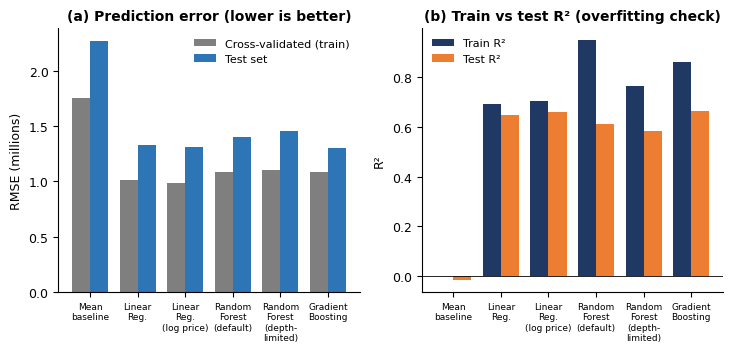

In [19]:
# Figure 7: model comparison and overfitting diagnostic
short = {"Mean baseline": "Mean\nbaseline", "Linear Regression": "Linear\nReg.",
         "Linear Regression (log price)": "Linear\nReg.\n(log price)", "Random Forest (default)": "Random\nForest\n(default)",
         "Random Forest (depth-limited)": "Random\nForest\n(depth-\nlimited)", "Gradient Boosting": "Gradient\nBoosting"}
labels = [short[m] for m in res.model]
xx, w = np.arange(len(res)), 0.38
fig, ax = plt.subplots(1, 2, figsize=(7.4, 3.6))
ax[0].bar(xx - w/2, res.cv_rmse / 1e6, w, color=GREY, label="Cross-validated (train)")
ax[0].bar(xx + w/2, res.test_RMSE / 1e6, w, color=BLUE, label="Test set")
ax[0].set_xticks(xx); ax[0].set_xticklabels(labels, fontsize=6.5)
ax[0].set(ylabel="RMSE (millions)", title="(a) Prediction error (lower is better)"); ax[0].legend(frameon=False)
ax[1].bar(xx - w/2, res.train_R2, w, color=NAVY, label="Train R\u00b2")
ax[1].bar(xx + w/2, res.test_R2, w, color=ORANGE, label="Test R\u00b2")
ax[1].axhline(0, color="black", lw=0.6)
ax[1].set_xticks(xx); ax[1].set_xticklabels(labels, fontsize=6.5)
ax[1].set(ylabel="R\u00b2", title="(b) Train vs test R\u00b2 (overfitting check)"); ax[1].legend(frameon=False)
save_fig("fig7_model_comparison")

## 8. Final Evaluation, Error Analysis and Interpretation
### 8.1 Final model on the test set

In [20]:
best = models[best_name]
pred = best.predict(X_test_f)
res_test = metrics(best, X_test_f, y_test)
res_train = metrics(best, X_train_f, y_train)
mean_price = y.mean()
R["final"] = dict(name=best_name, test=res_test, train=res_train,
                  mae_pct_of_mean=100 * res_test["MAE"] / mean_price,
                  rmse_pct_of_mean=100 * res_test["RMSE"] / mean_price,
                  mean_price=mean_price)
pct_err = np.abs(pred - y_test) / y_test
R["final"]["within_10"] = float((pct_err <= 0.10).mean() * 100)
R["final"]["within_20"] = float((pct_err <= 0.20).mean() * 100)
R["final"]["median_abs_pct_err"] = float(pct_err.median() * 100)

print("Model:", best_name)
print("TEST :", {k: round(v, 3) for k, v in res_test.items()})
print("TRAIN:", {k: round(v, 3) for k, v in res_train.items()})
print(f"Test MAE = {100*res_test['MAE']/mean_price:.1f}% of mean price; RMSE = {100*res_test['RMSE']/mean_price:.1f}%")
print(f"Predictions within 10% of true price: {R['final']['within_10']:.1f}%  |  within 20%: {R['final']['within_20']:.1f}%")

Model: Linear Regression (log price)
TEST : {'MAE': 969728.141, 'MSE': 1725761218450.489, 'RMSE': 1313682.313, 'R2': 0.659}
TRAIN: {'MAE': 678641.063, 'MSE': 912369216929.982, 'RMSE': 955180.201, 'R2': 0.704}
Test MAE = 20.3% of mean price; RMSE = 27.6%
Predictions within 10% of true price: 26.6%  |  within 20%: 59.6%


### 8.2 Where does the model make errors?

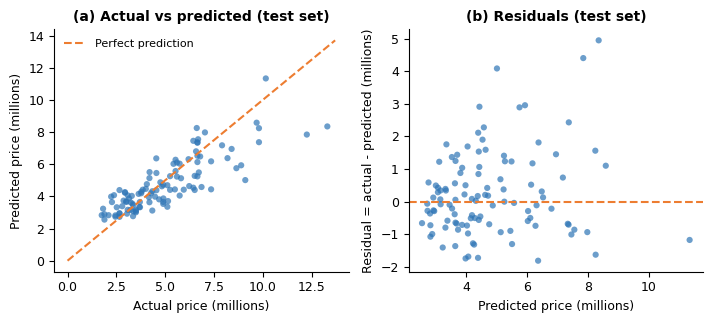

,n,MAE,mean_signed_error,median_pct_err
band,,,,
Lower third,39,659818.0,-501420.0,17.0
Middle third,23,670501.0,-2697.0,13.0
Upper third,47,1373318.0,966800.0,16.0


,actual,predicted,error,area,bedrooms,bathrooms,stories,airconditioning
0,13300000,8347677.0,4952323.0,7420,4,2,3,1
2,12250000,7842516.0,4407484.0,9960,3,2,2,0
15,9100000,5011573.0,4088427.0,6000,4,1,2,0
18,8890000,5931713.0,2958287.0,4600,3,2,2,1
55,7350000,4437346.0,2912654.0,6000,3,1,2,1


In [21]:
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.3))
lim = max(y_test.max(), pred.max()) / 1e6 * 1.03
ax[0].scatter(y_test / 1e6, pred / 1e6, s=20, alpha=0.7, color=BLUE, edgecolor="none")
ax[0].plot([0, lim], [0, lim], color=ORANGE, ls="--", label="Perfect prediction")
ax[0].set(xlabel="Actual price (millions)", ylabel="Predicted price (millions)", title="(a) Actual vs predicted (test set)")
ax[0].legend(frameon=False)
ax[1].scatter(pred / 1e6, resid / 1e6, s=20, alpha=0.7, color=BLUE, edgecolor="none")
ax[1].axhline(0, color=ORANGE, ls="--")
ax[1].set(xlabel="Predicted price (millions)", ylabel="Residual = actual - predicted (millions)", title="(b) Residuals (test set)")
save_fig("fig8_actual_vs_predicted")

# Error by price band (bands defined from the TRAINING prices)
q1, q2 = y_train.quantile([1/3, 2/3])
band = pd.cut(y_test, [-np.inf, q1, q2, np.inf], labels=["Lower third", "Middle third", "Upper third"])
eb = pd.DataFrame({"band": band, "abs_err": np.abs(resid), "signed": resid, "pct": pct_err * 100}) \
       .groupby("band", observed=True).agg(n=("abs_err", "size"), MAE=("abs_err", "mean"),
                                           mean_signed_error=("signed", "mean"), median_pct_err=("pct", "median"))
R["error_by_band"] = eb.reset_index().to_dict("records")
display(eb.round(0))

worst = pd.DataFrame({"actual": y_test, "predicted": pred.round(0), "error": resid.round(0)}) \
          .join(X_test[["area", "bedrooms", "bathrooms", "stories", "airconditioning"]]) \
          .assign(abs_err=lambda d: d.error.abs()).sort_values("abs_err", ascending=False).head(5).drop(columns="abs_err")
R["worst5"] = worst.reset_index(drop=True).to_dict("records")
display(worst)

### 8.3 What drives price? Interpreting the model
To make the model readable, a linear regression on `log(price)` is fitted on the training data (this is an *interpretation* model; the coefficients of a log-price model translate into approximate **percentage** effects: a coefficient *b* on a yes/no or count feature means a price change of (e^b - 1) x 100 %). A second fit on standardised features ranks features by influence.

,feature,coef,std_coef,effect_pct
12,log_area,0.296,0.118,NaN
1,bathrooms,0.185,0.088,20.306
2,stories,0.083,0.071,8.620
7,airconditioning,0.146,0.067,15.678
9,prefarea,0.133,0.056,14.251
11,furnishingstatus_unfurnished,-0.115,-0.053,-10.842
5,basement,0.104,0.050,10.974
3,mainroad,0.089,0.031,9.295
6,hotwaterheating,0.132,0.029,14.094
8,parking,0.033,0.028,3.367


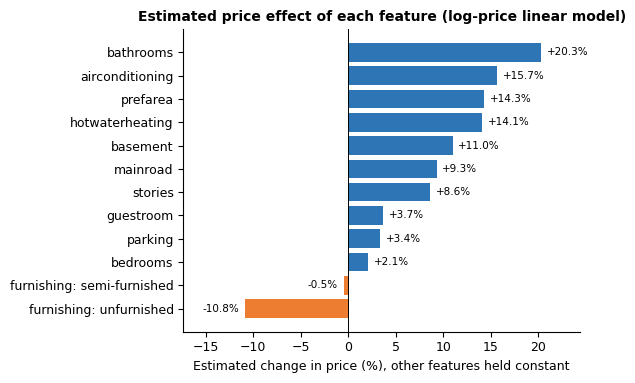

In [22]:
interp = LinearRegression().fit(X_train_f, np.log(y_train))
std_fit = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_f, np.log(y_train))
coefs = pd.DataFrame({"feature": final_features, "coef": interp.coef_,
                      "std_coef": std_fit[-1].coef_})
coefs["effect_pct"] = (np.exp(coefs.coef) - 1) * 100
coefs.loc[coefs.feature == "log_area", "effect_pct"] = np.nan            # elasticity, interpreted separately
coefs = coefs.reindex(coefs.std_coef.abs().sort_values(ascending=False).index)
R["coef_table"] = coefs.to_dict("records")
R["area_elasticity"] = float(coefs.loc[coefs.feature == "log_area", "coef"].iloc[0])
R["interp_train_r2"] = float(interp.score(X_train_f, np.log(y_train)))
display(coefs.round(3))

plot = coefs[coefs.feature != "log_area"].sort_values("effect_pct")
fig, ax = plt.subplots(figsize=(6.0, 3.9))
colors = [BLUE if v >= 0 else ORANGE for v in plot.effect_pct]
labels9 = plot.feature.str.replace("furnishingstatus_", "furnishing: ")
ax.barh(labels9, plot.effect_pct, color=colors)
for i, v in enumerate(plot.effect_pct):
    ax.text(v + (0.6 if v >= 0 else -0.6), i, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right", fontsize=7.5)
ax.axvline(0, color="black", lw=0.7)
ax.set(xlabel="Estimated change in price (%), other features held constant",
       title="Estimated price effect of each feature (log-price linear model)")
ax.set_xlim(plot.effect_pct.min() * 1.6, plot.effect_pct.max() * 1.2)
save_fig("fig9_feature_effects")

### 8.4 Supplementary figure (Appendix B of the report)

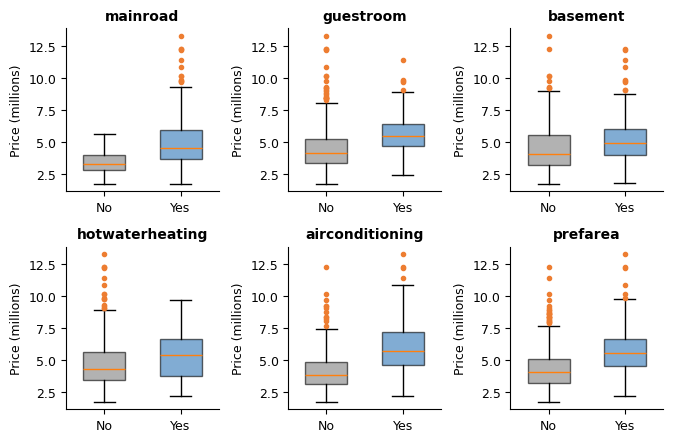

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(6.8, 4.5))
for ax, c in zip(axes.ravel(), binary_cols):
    grp = [df.loc[df[c] == v, "price"] / 1e6 for v in ("no", "yes")]
    bp = ax.boxplot(grp, labels=["No", "Yes"], patch_artist=True, widths=0.55,
                    flierprops=dict(marker="o", markersize=3, markerfacecolor=ORANGE, markeredgecolor=ORANGE))
    for patch, col in zip(bp["boxes"], (GREY, BLUE)): patch.set_facecolor(col); patch.set_alpha(0.6)
    ax.set(title=c, ylabel="Price (millions)")
save_fig("figA1_price_boxplots_by_feature")

## 9. Save Results

In [24]:
with open("results.json", "w") as f:
    json.dump(py(R), f, indent=2)
print("Saved results.json with", len(R), "result groups.")
print("Figures saved:", sorted(os.listdir("figures")))

Saved results.json with 25 result groups.
Figures saved: ['fig1_price_distribution.png', 'fig2_area_distribution.png', 'fig3_amenities_median_price.png', 'fig4_price_by_characteristics.png', 'fig5_area_vs_price.png', 'fig6_correlation_heatmap.png', 'fig7_model_comparison.png', 'fig8_actual_vs_predicted.png', 'fig9_feature_effects.png', 'figA1_price_boxplots_by_feature.png']
